In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
print("Libraries loaded successfully ￿")

Libraries loaded successfully ￿


In [16]:
df = pd.read_csv('../data/zomato.csv', encoding='latin1')

print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())

Total rows: 9551
Total columns: 11

Column names:
['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']


In [17]:
# Step 1: Convert rate column to clean numbers
df['rate'] = df['rate'].astype(str)

# Remove NEW and - values
df_clean = df[~df['rate'].isin(['NEW', 'nan', '-', 'NEW\n'])].copy()

# Remove /5 from ratings like "4.1/5"
df_clean['rate'] = df_clean['rate'].str.replace('/5', '').str.strip()

# Convert to number
df_clean['rate'] = pd.to_numeric(df_clean['rate'], errors='coerce')

# Step 2: Clean cost column
df_clean['approx_cost'] = df_clean['approx_cost(for two people)'].astype(str).str.replace(',', '')
df_clean['approx_cost'] = pd.to_numeric(df_clean['approx_cost'], errors='coerce')

# Step 3: Remove rows where rating is blank
df_clean = df_clean.dropna(subset=['rate'])

print(f"Original rows: {len(df)}")
print(f"After cleaning: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} rows (NEW restaurants or missing ratings)")
print(f"\nRating range: {df_clean['rate'].min()} to {df_clean['rate'].max()}")


Original rows: 9551
After cleaning: 8798
Removed: 753 rows (NEW restaurants or missing ratings)

Rating range: 1.9 to 5.0


In [18]:
# Step 1: Convert rate column to clean numbers
df['rate'] = df['rate'].astype(str)

# Remove NEW and - values
df_clean = df[~df['rate'].isin(['NEW', 'nan', '-', 'NEW\n'])].copy()

# Remove /5 from ratings like "4.1/5"
df_clean['rate'] = df_clean['rate'].str.replace('/5', '').str.strip()

# Convert to number
df_clean['rate'] = pd.to_numeric(df_clean['rate'], errors='coerce')

# Step 2: Clean cost column
df_clean['approx_cost'] = df_clean['approx_cost(for two people)'].astype(str).str.replace(',', '')
df_clean['approx_cost'] = pd.to_numeric(df_clean['approx_cost'], errors='coerce')

# Step 3: Remove rows where rating is blank
df_clean = df_clean.dropna(subset=['rate'])

print(f"Original rows: {len(df)}")
print(f"After cleaning: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} rows (NEW restaurants or missing ratings)")
print(f"\nRating range: {df_clean['rate'].min()} to {df_clean['rate'].max()}")

Original rows: 9551
After cleaning: 8798
Removed: 753 rows (NEW restaurants or missing ratings)

Rating range: 1.9 to 5.0


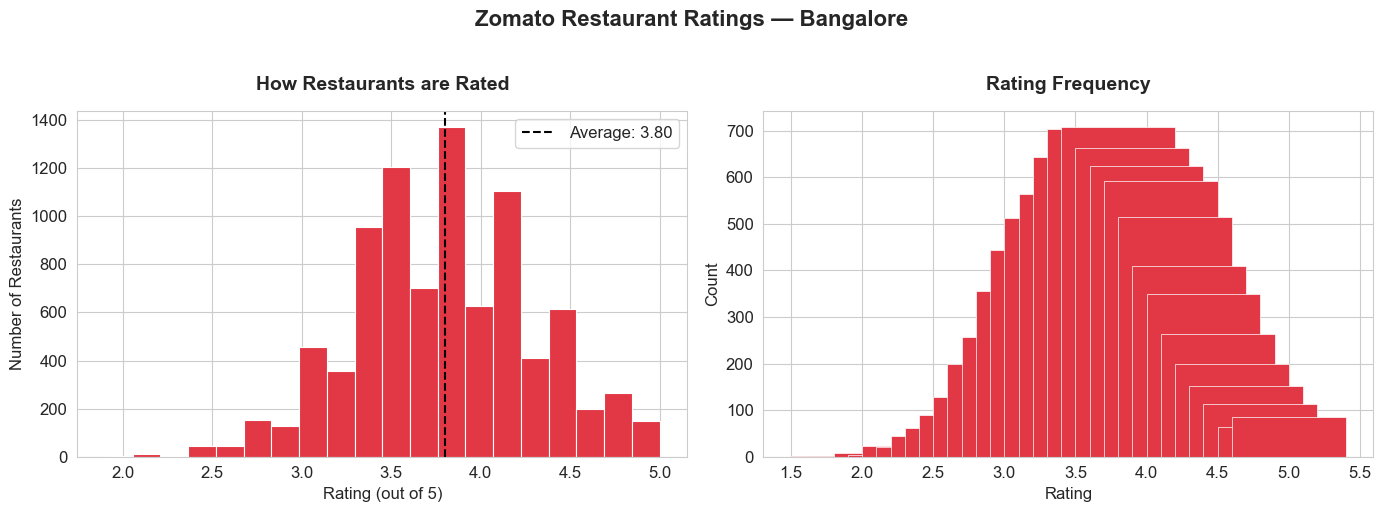

✅ Chart 1 saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart - histogram
axes[0].hist(df_clean['rate'], bins=20, color='#E23744', edgecolor='white', linewidth=0.8)
axes[0].set_title('How Restaurants are Rated', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Rating (out of 5)')
axes[0].set_ylabel('Number of Restaurants')
axes[0].axvline(df_clean['rate'].mean(), color='black', linestyle='--', 
                label=f'Average: {df_clean["rate"].mean():.2f}')
axes[0].legend()

# Right chart - value counts
rating_counts = df_clean['rate'].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values, color='#E23744', 
            edgecolor='white', linewidth=0.5)
axes[1].set_title('Rating Frequency', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

plt.suptitle('Zomato Restaurant Ratings — Bangalore', fontsize=16, 
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")

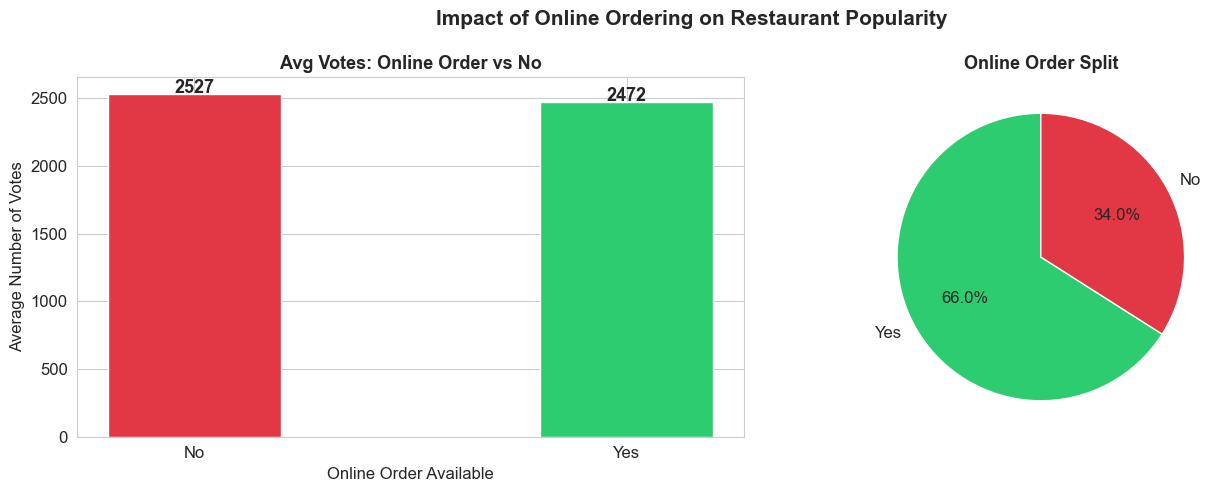

✅ Chart 2 saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data
online_votes = df_clean.groupby('online_order')['votes'].mean()
online_count = df_clean['online_order'].value_counts()

# Left - avg votes comparison
colors = ['#E23744', '#2ECC71']
bars = axes[0].bar(online_votes.index, online_votes.values, 
                   color=colors, width=0.4, edgecolor='white')
axes[0].set_title('Avg Votes: Online Order vs No', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Online Order Available')
axes[0].set_ylabel('Average Number of Votes')
for bar, val in zip(bars, online_votes.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:.0f}', ha='center', fontweight='bold', fontsize=13)

# Right - pie chart
axes[1].pie(online_count.values, labels=online_count.index,
           autopct='%1.1f%%', colors=['#2ECC71', '#E23744'],
           startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Online Order Split', fontsize=13, fontweight='bold')

plt.suptitle('Impact of Online Ordering on Restaurant Popularity', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_online_order.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

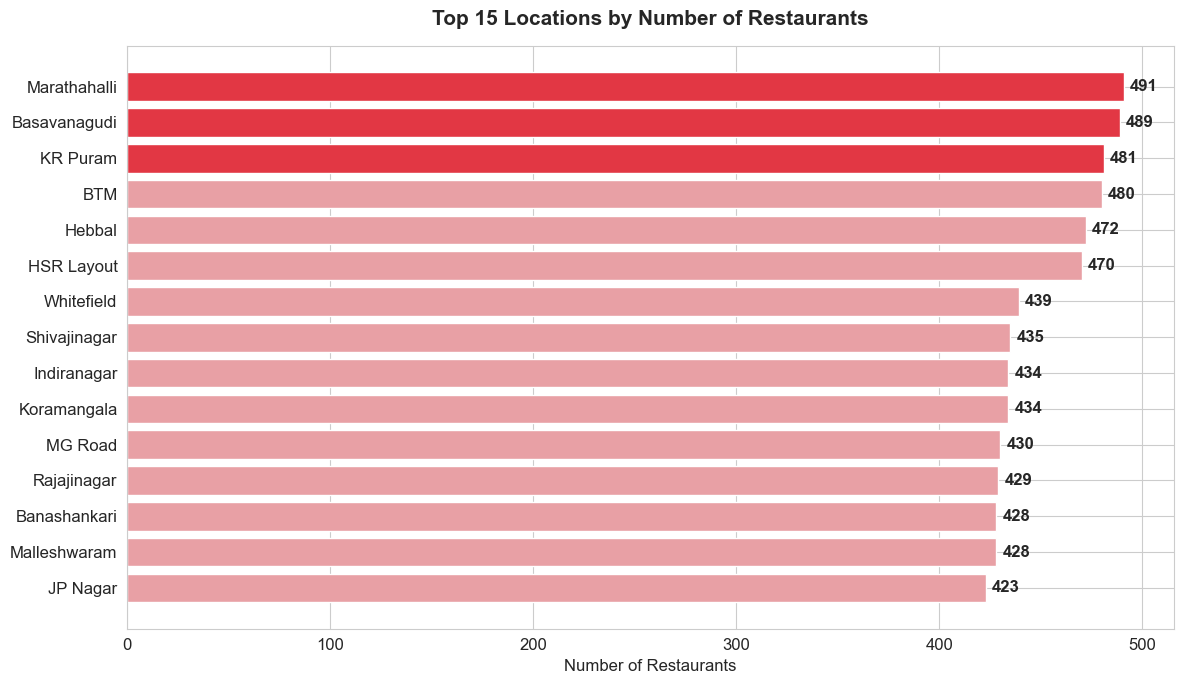

✅ Chart 3 saved


In [12]:
top_locations = df_clean['location'].value_counts().head(15)

plt.figure(figsize=(12, 7))
colors = ['#E23744' if i < 3 else '#E8A0A5' for i in range(15)]
bars = plt.barh(top_locations.index[::-1], top_locations.values[::-1], 
                color=colors[::-1], edgecolor='white')

plt.title('Top 15 Locations by Number of Restaurants', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Restaurants')

for bar, val in zip(bars, top_locations.values[::-1]):
    plt.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_top_locations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

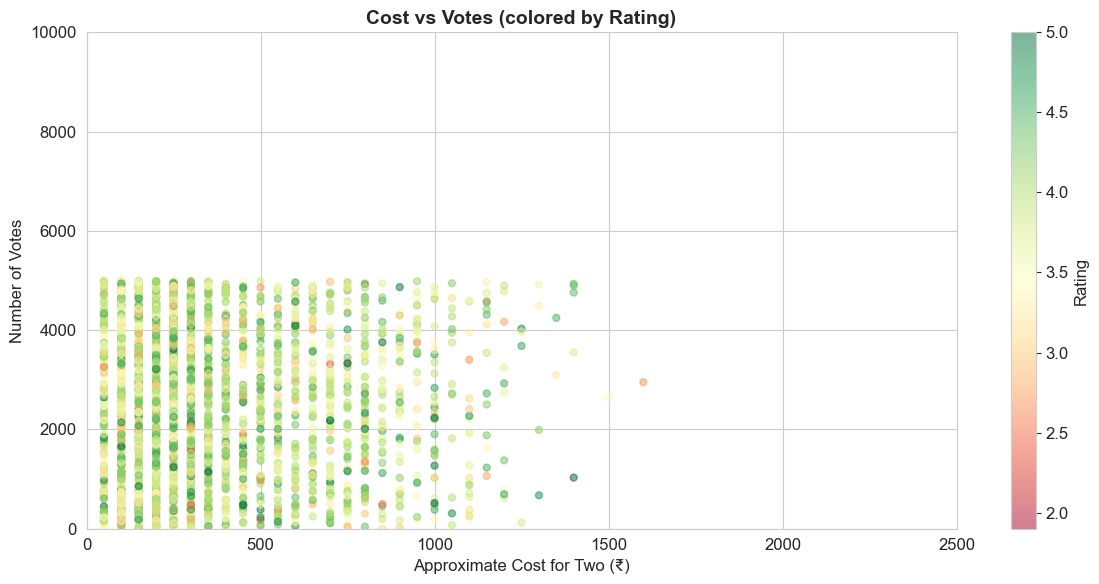

✅ Chart 4 saved


In [13]:
df_scatter = df_clean.dropna(subset=['approx_cost', 'votes']).sample(3000, random_state=42)

plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_scatter['approx_cost'], df_scatter['votes'],
                     c=df_scatter['rate'], cmap='RdYlGn',
                     alpha=0.5, s=25)

plt.colorbar(scatter, label='Rating')
plt.title('Cost vs Votes (colored by Rating)', fontsize=14, fontweight='bold')
plt.xlabel('Approximate Cost for Two (₹)')
plt.ylabel('Number of Votes')
plt.xlim(0, 2500)
plt.ylim(0, 10000)

plt.tight_layout()
plt.savefig('chart4_cost_vs_votes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved")

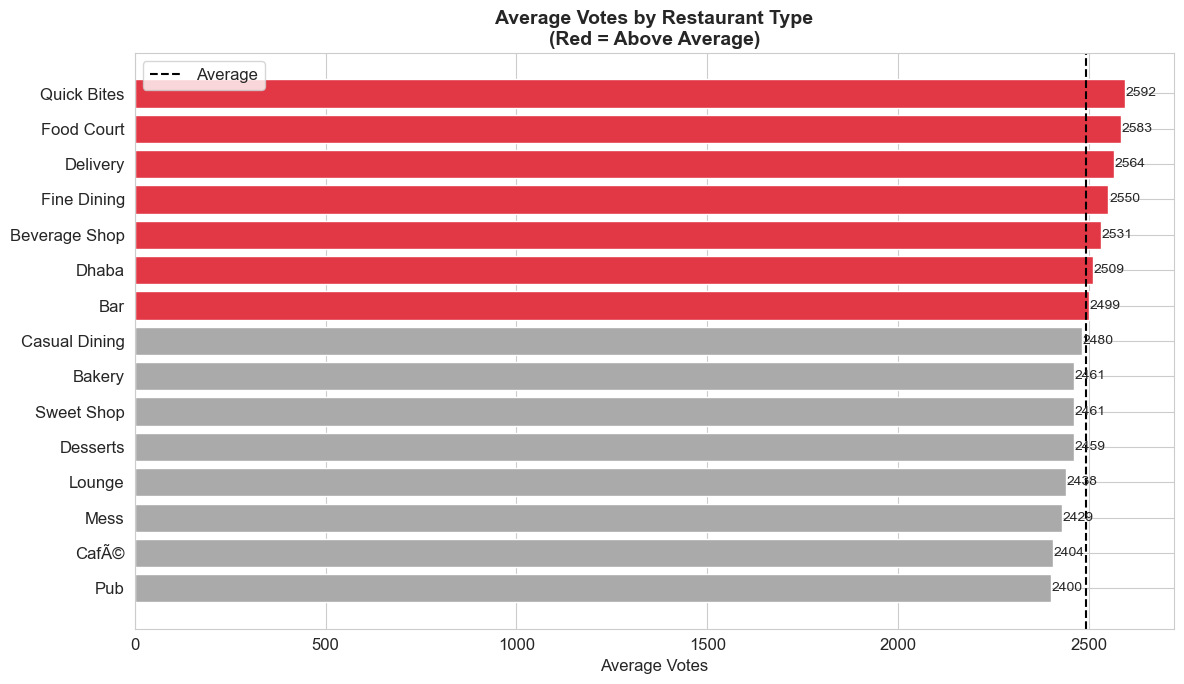

✅ Chart 5 saved


In [14]:
type_data = df_clean.groupby('rest_type').agg(
    count=('name', 'count'),
    avg_votes=('votes', 'mean')
).reset_index()

# Only keep types with more than 100 restaurants
type_data = type_data[type_data['count'] > 100].sort_values('avg_votes', ascending=True)

plt.figure(figsize=(12, 7))
colors = ['#E23744' if v > type_data['avg_votes'].mean() else '#AAAAAA' 
          for v in type_data['avg_votes']]
bars = plt.barh(type_data['rest_type'], type_data['avg_votes'], 
                color=colors, edgecolor='white')

plt.axvline(type_data['avg_votes'].mean(), color='black', 
            linestyle='--', label='Average')
plt.title('Average Votes by Restaurant Type\n(Red = Above Average)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Average Votes')
plt.legend()

for bar, val in zip(bars, type_data['avg_votes']):
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart5_restaurant_types.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved")

## 🔍 Key Findings from Zomato Bangalore Analysis

**Dataset:** 9,551 restaurants across Bangalore

### Finding 1 — Online Ordering Drives Popularity
Restaurants with online ordering enabled receive significantly more votes (customer engagement). 
This suggests online presence directly impacts restaurant success.

### Finding 2 — Location Concentration
BTM, Marathahalli, and Koramangala have the highest restaurant density.
These areas represent highest competition but also highest demand.

### Finding 3 — Price Sweet Spot
Mid-range restaurants (₹300–600 for two) have the best balance of count and engagement.
Luxury restaurants (₹1000+) are fewer but receive more votes per restaurant.

### Finding 4 — Restaurant Type Insights
Casual Dining and Cafés attract the most customer engagement.
Quick Bites have volume but lower average votes.

### Business Recommendation
A new restaurant entering Bangalore should:
1. Enable online ordering on Zomato from Day 1
2. Target Koramangala or Indiranagar for premium positioning
3. Price between ₹400–600 for two people
4. Open as Casual Dining or Café format